# <u>Project 6 - Code Breaking with Statistical Physics

##### __Authors:__ Alex Bell, Lucy Burchell, Hong Chen, Bingxiang Hu, Zoe Morton.

# <u>Table of Contents
* [Introduction](#Introduction)
* [Preliminaries](#Preliminaries)
* [Section1: Simple Cyclic Shifts](#Section1)
* [Section2: Working with Frequencies](#Section2)
  * [2.1: Further Work with Frequencies](#Section2.1)
* [Section3: Applying Statistical Physics](#Section3)
  * [3.1: The Metropolis Algorithm](#Section3.1)
* [Section4: Improvements and Analysis](#Section4)
  * [4.1: Adapting the Metropolis Algorithm](#Section4.1)
    * [4.1.1 Trigrams](#Trigrams)
    * [4.1.2 Word Analysis](#Word_Analysis)
    * [4.1.3 Different Languages](#Different_Languages)
  * [4.2: Frequency Analysis Adjustment](#Section4.2)
  * [4.3: Using Graphical Representations](#Section4.3)
* [Results](#Results)
* [Conclusion](#Conclusion)
* [Bibliography](#Bibliography)

<a id="Introduction"></a>
## <u>Introduction

National security, personal privacy and QR codes (1) are some examples of how code breaking is used everyday. In this project, we explore potential methods used to decrypt coded messages with a particular focus on statistical physics. We aim to analyse the effectiveness of these methods by attempting to decrypt twelve encrypted messages, of which have varying difficulty, thus requiring different deciphering methods. 

<a id="Preliminaries"></a>
## <u>Preliminaries

Run the cell below to import the necessary libraries before continuing with this notebook.

In [19]:
import nbformat
import requests
import re
%run get_coded_message.ipynb         # Creates a path to easily reference our coded messages
import math
import random
from collections import Counter
import matplotlib.pyplot as plt
!pip install translate

LOJ WUZCWKCTFHHFHTWUZFHQWMZEUW EAWKCWUZCWCHV


<a id="Section1"></a>
## <u>Section1
## <u>Section 1: Simple Cyclic Shifts

In this section, we introduce a simple cyclic shift applied to a set of 27 characters (the alphabet plus the 'space' character). We will continue to use this throughout the project and store these characters in a list. 

By defining a new function to receive this list, and apply a cyclic shift of a variable number, we can easily map each letter to its shifted character.

As an example, we will apply this cyclic shift function to our first coded message to decode it.

#### Coded Message:

> 1\. GPKZFER JRSER EKWIGIWKWVRZ YZRCWMWCRSEVRYWEWISCRGLIGFJWRGIFYISDD EYRCSEYLSYWRGPKZFEJRVWJ YERGZ CFJFGZPRWDGZSJ QWJRUFVWRIWSVST C KPRN KZR KJREFKSTCWRLJWRFXRJ YE X USEKR EVWEKSK FER KJRCSEYLSYWRUFEJKILUKJRSEVRFTAWUKRFI WEKWVRSGGIFSUZRS DRKFRZWCGRGIFYISDDWIJRNI KWRUCWSIRCFY USCRUFVWRXFIRJDSCCRSEVRCSIYWRJUSCWRGIFAWUKJ

#### Method:

Our initial thought was to identify the most frequent character within the coded message, assuming this must be the ciphered 'space' character. By using a search function, we determined this to be 'R'.

From here, we calculated the cyclic shift (from the coded message to our character list) and translated our method into Python:

In [20]:
# Check the correct coded message was received
print(get_coded_message(0))

GPKZFER JRSER EKWIGIWKWVRZ YZRCWMWCRSEVRYWEWISCRGLIGFJWRGIFYISDD EYRCSEYLSYWRGPKZFEJRVWJ YERGZ CFJFGZPRWDGZSJ QWJRUFVWRIWSVST C KPRN KZR KJREFKSTCWRLJWRFXRJ YE X USEKR EVWEKSK FER KJRCSEYLSYWRUFEJKILUKJRSEVRFTAWUKRFI WEKWVRSGGIFSUZRS DRKFRZWCGRGIFYISDDWIJRNI KWRUCWSIRCFY USCRUFVWRXFIRJDSCCRSEVRCSIYWRJUSCWRGIFAWUKJ


In [21]:
# Define our list of 27 characters that we will continue to use throughout the project
character_list = ["A" , "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", 
                  "N", "O", "P", "Q", "R", "S", "T", "U", "V", "W", "X", "Y", "Z", " "]

The "R" character is 9 shifts away from the space character.  Thus we can define a function that performs this shift.

In [22]:
# Define the cyclic shift function
shift = 9

def cyclic_shift(cipher_letter):
    
    cipher_index = character_list.index(cipher_letter)   # Run through each letter in the list
    character_index = (cipher_index + shift) % 27        # Perform the shift on the index (allowing the list to loop)
    
    decipher_letter = character_list[character_index]    # Apply the shift to receive the new character from our list

    return decipher_letter

We can test that our previous logic is correctly converted to code by seeing which character "R" is shifted to and doing similiar for all of the characters.

In [23]:
# Test the function works
cyclic_shift('R')

' '

In [24]:
# For completeness, here is a list of all the cyclic shifts for this particular message:
for letter in character_list:
    print(f'{letter} --> {cyclic_shift(letter)}')

A --> J
B --> K
C --> L
D --> M
E --> N
F --> O
G --> P
H --> Q
I --> R
J --> S
K --> T
L --> U
M --> V
N --> W
O --> X
P --> Y
Q --> Z
R -->  
S --> A
T --> B
U --> C
V --> D
W --> E
X --> F
Y --> G
Z --> H
  --> I


We can apply this information to a coded message in order to return a fully deciphered message. 

In [25]:
# Define a decoding function
def message_decoder(coded_message):

    deciphered_message = ''

    for i in range(0, len(coded_message),):
        
        current_letter = coded_message[i]                 # Takes individual coded letter from the full coded message

        deciphered_letter = cyclic_shift(current_letter)  # Applies the cyclic shift to each letter

        deciphered_message += deciphered_letter           # Adds these decoded letters to our deciphered message

    return deciphered_message                             # Returns the fully decoded message

In [26]:
# Apply this function to our first coded message
message_decoder(get_coded_message(0))

'PYTHON IS AN INTERPRETED HIGH LEVEL AND GENERAL PURPOSE PROGRAMMING LANGUAGE PYTHONS DESIGN PHILOSOPHY EMPHASIZES CODE READABILITY WITH ITS NOTABLE USE OF SIGNIFICANT INDENTATION ITS LANGUAGE CONSTRUCTS AND OBJECT ORIENTED APPROACH AIM TO HELP PROGRAMMERS WRITE CLEAR LOGICAL CODE FOR SMALL AND LARGE SCALE PROJECTS'

##### The fully decoded message (written with correct punctuation) is:

>Python is an interpreted, high level, and general purpose programming language. Python's design philosophy EMP hasizes code readability with it's notable use of significant indentation. Its language constructs and object-oriented approach aim to help programmers write clear, logical code for small and large-scale projects.

<a id="Section2"></a>
## <u>Section2
## <u>Working with Frequencies

Whilst section one shows that an encrypted message built using simple cyclic shifts can be decoded "by hand", other encryptions that use arbitrary permutations make the above method impractical. Therefore, we will explore how we could instead use certain statistics of the coded messages. The idea is to permute the characters in our message to a corresponding character in our alphabet and space list based upon the frequencies. We can then track whether the readability of the message increases/improves as we perform these shifts.

To do this we need to know two things: the frequencies of the 27 characters generally in the English language and the frequencies of the 27 characters in the coded message.

The frequencies of the 27 characters in the English language can be approximated by the frequencies in a large body of English text, for example Moby-dick by Herman Melville (2). We are only interested in the characters in our list so we must remove all punctuation from the text and capitalise all of the letters. Note, it is also important that the number of spaces does not change during this transformation of the Moby-dick text, as space is one of the 27 characters. 

#### To import the Moby_dick text:

In [27]:
# THIS CELL ONLY NEEDS TO BE RUN ONCE
# Goes to the URL below and writes the contents of the book Moby-dick to a file called moby.txt
# Then saves the text to a list
url = "http://www.gutenberg.org/files/2701/2701-0.txt"
moby = requests.get(url).text
def get_text(url,file_name):
    file = requests.get(url).text

    try:                           
        f = open(file_name,"x")   # Creates the file the first time
    except FileExistsError:       # But is skipped if the file already exists
        pass
    
        
    with open(file_name,"w",errors = "ignore") as f:
        f.write(file)  # Write to file
    with open(file_name,"r",errors = "ignore") as f:
        file = f.read()  # Read from file
    
    # We want to make all the letters upper case
    file = file.upper()
    # Then we remove anything that isn't an upper case letter, a new line, or a space
    file = re.sub(r'[^A-Z\s]', ' ', file)
    # and then remove any additional spaces that weren't in the original text
    file = re.sub(r' +', ' ', file)
    # Finally remove any newlines and replaces them with spaces
    file = re.sub(r'\n', ' ', file)
    file = re.sub(r'\xa0', ' ', file)

    return file

moby_new = get_text(url, "moby.txt")

#### Exploring Frequencies:

We can find the frequencies of the 27 characters for any imported text, for example for our large sample text.

In [28]:
# Count the number of each character that appears in our imported text
for i in range(27):
    frequency = moby_new.count(character_list[i])
    print(character_list[i], frequency)

A 78224
B 16936
C 22718
D 38311
E 117511
F 20880
G 20875
H 63239
I 65586
J 1088
K 8087
L 42875
M 23325
N 65760
O 69457
P 17443
Q 1570
R 52419
S 64390
T 88391
U 26697
V 8614
W 22264
X 1036
Y 16899
Z 634
  228388


We can test this method will work for other texts using a random string of the 27 characters:

In [29]:
# Testing Cell to interact with the frequencies of different texts
# We can build a list of 100 random characters (we can change the length)
random_chars= [random.choice(character_list) for _ in range(100)]
# Then we can build a string of random characters to then test the frequency operation above
random_text= "".join(random_chars)
print("Our random text is " +str(random_text))
# Count the number of each character that appears in our random text
for i in range(27):
    frequency = random_text.count(character_list[i])
    print(character_list[i], frequency)

Our random text is FPFTZGIKJN KQ  QUMX ROTJP  BLADQAFQOIMSRVZQFGTVTQKKNHZZLVBGZQTDXLSIUZLQBLKNOCOTNGYZKJUYZQZTSYJKVGFXQ
A 2
B 3
C 1
D 2
E 0
F 5
G 5
H 1
I 3
J 4
K 7
L 5
M 2
N 4
O 4
P 2
Q 10
R 2
S 3
T 7
U 3
V 4
W 0
X 3
Y 3
Z 9
  6


Now that we have our large English text prepared and are satisfied that the frequency method works for any text (random or not), we can find the frequency of each of the 27 characters and then sort them. We can then repeat for any of the coded messages. 

To do so, we define a get_frequency function that returns a list of tuples where the first entry is the character and the second is the frequency, relative to the total, sorted from most common/frequent to least.

In Python this translates to the following code:

In [30]:
# ALL ENCODED TEXT IS ASSUMED TO BE UPPERCASE

# Defining a new function that takes in a string (could be a large example of English or a specific encoded piece of text)
def get_frequency(text):
    length = len(text)
    frequency = []

    for char in character_list:
        # To calculate the fraction of the text each letter makes up
        if char == " ":
            frequency.append((char,(text.count(char)+text.count("\n"))/length))    
            
        else:
            frequency.append((char,text.count(char)/length))
            
    # Returns a list containing tuples of each letter and its frequency, sorted by frequency
    return sorted(frequency, key = lambda x: x[1])[::-1]    # Sorts the list by the second entry in each tuple and then reverses it

Now we want to use our knowledge of the character frequencies to decipher the coded message. 

First we define a function that for a coded message will return what each of the characters should map to, based upon their position in the "most to least frequent" list. This is a letter mapping.

In [31]:
# Defining a new function that takes in an encoded string and list containing tuples of each letter and its frequency, sorted by frequency (can be found from get_frequency)
def get_letter_map_from_frequency(ciphertext,english_frequencies,verbose = False):
    out = {}
    text_freq = get_frequency(ciphertext)
    print("The frequencies in the text are: \n")
    if verbose:
        for pair in text_freq:
            print(f"{pair[0]}: {pair[1]}")
    for i in range(len(text_freq)):
        encoded_letter = text_freq[i][0]
        english_letter = english_frequencies[i][0]

        out[encoded_letter] = english_letter
    # Returns a dictionary mapping the most common letters in the encoded string with the most common letters in English
    return out

We need a function that for each character in the coded message returns the character it represents according to our letter mapping. Thus if the input is a string of multiple characters, the output will be a new string of equal characters with the map applied.

In [32]:
# Defining a new function that takes in a string to be decoded and a dictionary with the encoded letters as keys and their respective decoded letters as values
def decode(ciphertext,letter_map):
    out = ""
    for char in ciphertext:
        if char != "\n":
            out += letter_map[char]
        else:
            out += letter_map[" "]
    # Returns a decoded string
    return out

As an example we can apply our work to the second coded message:

#### Coded Message:

>2\. RECFV KUWE VJCRWQFCRCFICYWEZRWKLVJWQF SCRRZ ALVWJLAACFWNATZVW NFWIZRZT FWELYWVCSTWNRWLVTE NBEWZTWHLRWCLRMWS FWJCWHE WUACHWEZJWR WHCVVWT WRCCWTELTWECWHLRWQF S NAYVMWCPKZTCYWTECWJ JCATWTELTWEZVT AWKNGZTTWRWGF LYWGLKUWELYWYZRLQQCLFCYWTEF NBEWTECWY FWJMWK JFLYCWFNRECYWT WTECWTLGVCWVLZYW NTWLVVWTECWRVZQRW SWQLQCFWK ATLZAZABWYLAKZABWJCAWZAWSF ATW SWEZJWLAYWTEFCHWEZJRCVSWZAT WLAWZATFZKLTCWLAYWCVLG FLTCWKLVKNVLTZ AWS FWTH WE NFRWZWHLTKECYWEZJWLRWECWK ICFCYWRECCTWLSTCFWRECCTW SWQLQCFWHZTEWSZBNFCRWLAYWVCTTCFRWR WK JQVCTCVMWLGR FGCYWZAWEZRWTLRUWTELTWECWELYWCIZYCATVMWS FB TTCAWJMWQFCRCAKCWR JCTZJCRWECWHLRWJLUZABWQF BFCRRWLAYWHEZRTVCYWLAYWRLABWLTWEZRWH FUWR JCTZJCRWECWHLRWQNDDVCYWLAYWH NVYWRZTWS FWV ABWRQCVVRWHZTEWLWSNFF HCYWGF HWLAYWLWILKLATWCMCWSZALVVMWECWRQFLABWSF JWEZRWKELZFWHZTEWLWKFMW SWRLTZRSLKTZ AWLAYWHLVUCYWNQWLAYWY HAWTECWF JWFNGGZABWEZRWELAYRWT BCTECFWTECAWECWHF TCWLWV ABWTCVCBFLJWNQ AWLWKLGVCWS FJWZSWJMWLARHCFWT WTEZRWZRWLRWZWE QCWM NWHZVVWELICWLWICFMWQFCTTMWKLRCWT WLYYWT WM NFWK VVCKTZ AWHLTR AWRLZYWECWZWCPQCKTWTELTWHCWRELVVWGCWLGVCWT WB WY HAWT WA FS VUWT J FF HWLAYWT WTLUCW NFWSFZCAYWR JCWICFMWYCSZAZTCWACHRWLRWT WTECWRCKFCTW SWEZRWLAA MLAKCWZWK ASCRRWTELTWZWHLRWSZVVCYWHZTEWKNFZ RZTMWGNTWZWHLRWLHLFCWTELTWE VJCRWVZUCYWT WJLUCWEZRWYZRKV RNFCRWLTWEZRW HAWTZJCWLAYWZAWEZRW HAWHLMWR WZWHLZTCYWNATZVWZTWRE NVYWRNZTWEZJWT WTLUCWJCWZAT WEZRWK ASZYCAKCWGNTWTECFCWHLRWLWYCVLMWZAWTELTWLARHCFZABWTCVCBFLJWLAYWTH WYLMRW SWZJQLTZCAKCWS VV HCYWYNFZABWHEZKEWE VJCRWQFZKUCYWNQWEZRWCLFRWLTWCICFMWFZABW SWTECWGCVVW AWTECWCICAZABW SWTECWRCK AYWTECFCWKLJCWLWVCTTCFWSF JWEZVT AWKNGZTTWLVVWHLRWXNZCTWHZTEWEZJWRLICWTELTWLWV ABWZARKFZQTZ AWELYWLQQCLFCYWTELTWJ FAZABWNQ AWTECWQCYCRTLVW SWTECWRNAYZLVWECWZAKV RCYWLWK QMW SWZTWHEZKEWZRWECFCWFCQF YNKCYWCVRZCWQFCQLFCWT WJCCTWTEMWB YWE VJCRWGCATW ICFWTEZRWBF TCRXNCWSFZCDCWS FWR JCWJZANTCRWLAYWTECAWRNYYCAVMWRQFLABWT WEZRWSCCTWHZTEWLAWCPKVLJLTZ AW SWRNFQFZRCWLAYWYZRJLMWEZRWSLKCWHLRWELBBLFYWHZTEWLAPZCTM

In [33]:
# Assign our coded message to a variable (so it could easily be changed in the future)
ciphertext = get_coded_message(1)
moby_clean = moby_new

print(f'The length of our coded message is: {len(ciphertext)}\n')

# Decode the message using the frequencies
english_frequencies = get_frequency(moby_new)
letter_map = get_letter_map_from_frequency(ciphertext,english_frequencies)
output = decode(ciphertext,letter_map)
print(output)

print(f'\nThe length of our output message is: {len(output)}')   # Should be the same as the coded message length

The length of our coded message is: 1944

The frequencies in the text are: 

ISERLOCV SOLMEI GREIERKED SNI CALM GROWEIINOHAL MAHHER FHTNL OFR KNINTOR SAD LEWT FI ALTSOFPS NT UAI EAIB WOR ME USO VHEU SNM IO UELL TO IEE TSAT SE UAI GROWOFHDLB EQCNTED TSE MOMEHT TSAT SNLTOH CFYNTT I YROAD YACV SAD DNIAGGEARED TSROFPS TSE DOR MB COMRADE RFISED TO TSE TAYLE LAND OFT ALL TSE ILNGI OW GAGER COHTANHNHP DAHCNHP MEH NH WROHT OW SNM AHD TSREU SNMIELW NHTO AH NHTRNCATE AHD ELAYORATE CALCFLATNOH WOR TUO SOFRI N UATCSED SNM AI SE COKERED ISEET AWTER ISEET OW GAGER UNTS WNPFREI AHD LETTERI IO COMGLETELB AYIORYED NH SNI TAIV TSAT SE SAD EKNDEHTLB WORPOTTEH MB GREIEHCE IOMETNMEI SE UAI MAVNHP GROPREII AHD USNITLED AHD IAHP AT SNI UORV IOMETNMEI SE UAI GFJJLED AHD UOFLD INT WOR LOHP IGELLI UNTS A WFRROUED YROU AHD A KACAHT EBE WNHALLB SE IGRAHP WROM SNI CSANR UNTS A CRB OW IATNIWACTNOH AHD UALVED FG AHD DOUH TSE ROM RFYYNHP SNI SAHDI TOPETSER TSEH SE UROTE A LOHP TELEPRAM FGOH A CAYLE WORM NW MB AHIUER 

<a id="section2.1"></a>
### <u>Section2.1
#### <u>Working to improve our resulting messages further:

To further improve the readability of the string of characters, we can manually swap two characters in a partially deciphered message from the work above and then see if the message becomes an English sentence/phrase.

In Python, the following code achieves this idea:

In [34]:
# We want a function that swaps all of the occurences of one character with another, both are specified as the variables of the function
def swap_of_char(string, char_1, char_2):
    # If both letters are the same, the string will be as it originally was
    if char_1 == char_2: 
        return string
    else:
        # Using a temporary character $ to replace all of char_1
        string = string.replace(char_1, "$")
        # Replacing all of char_2 with char_1
        string = string.replace(char_2,char_1)
        # Finally replacing all of temporary character $ with char_2
        string = string.replace("$", char_2)
    return string

Our initial message is the result of the frequency letter mapping and permutations in the previous function. 

Then, using our knowledge of English words, we spotted potential swaps that would make the coded message incrementally closer to English. To begin we chose two random characters to swap, analysed what change occurred and by inspection chose a suitable next swap to be "W" and "F". We repeated this and more words became readable. 

Our final swap was focused on the part of the string which printed to "FRIEJE". We could not inspect/guess what the deciphered word was meant to be. Therefore, we researched this extract of what we found to be "The Adventure of the Dancing Men" (3) to find the word was meant to be "frieze" once fully decoded- justifying our final swap of "J" and "Z".

These efforts translate to the following calls of the swap_of_char function

In [35]:
# After seeing how this swap has affected the code, you can adjust the cipher by hand:
output = decode(ciphertext,letter_map)
output = swap_of_char(output, "P", "G")
output = swap_of_char(output, "W", "F")
output = swap_of_char(output, "I", "H")
output = swap_of_char(output, "S", "H")
output = swap_of_char(output, "I", "N")
output = swap_of_char(output, "V", "K")
output = swap_of_char(output, "W", "U")
output = swap_of_char(output, "B", "Y")
output = swap_of_char(output, "Q", "X")
swap_of_char(output, "J", "Z")

'SHERLOCK HOLMES PRESERVED HIS CALM PROFESSIONAL MANNER UNTIL OUR VISITOR HAD LEFT US ALTHOUGH IT WAS EASY FOR ME WHO KNEW HIM SO WELL TO SEE THAT HE WAS PROFOUNDLY EXCITED THE MOMENT THAT HILTON CUBITT S BROAD BACK HAD DISAPPEARED THROUGH THE DOR MY COMRADE RUSHED TO THE TABLE LAID OUT ALL THE SLIPS OF PAPER CONTAINING DANCING MEN IN FRONT OF HIM AND THREW HIMSELF INTO AN INTRICATE AND ELABORATE CALCULATION FOR TWO HOURS I WATCHED HIM AS HE COVERED SHEET AFTER SHEET OF PAPER WITH FIGURES AND LETTERS SO COMPLETELY ABSORBED IN HIS TASK THAT HE HAD EVIDENTLY FORGOTTEN MY PRESENCE SOMETIMES HE WAS MAKING PROGRESS AND WHISTLED AND SANG AT HIS WORK SOMETIMES HE WAS PUZZLED AND WOULD SIT FOR LONG SPELLS WITH A FURROWED BROW AND A VACANT EYE FINALLY HE SPRANG FROM HIS CHAIR WITH A CRY OF SATISFACTION AND WALKED UP AND DOWN THE ROM RUBBING HIS HANDS TOGETHER THEN HE WROTE A LONG TELEGRAM UPON A CABLE FORM IF MY ANSWER TO THIS IS AS I HOPE YOU WILL HAVE A VERY PRETTY CASE TO ADD TO YOUR COLLECT

The fully decoded message (with correct punctuation):
>Sherlock Holmes preserved his calm professional manner until our visitor had left us, although it was easy for me, who knew him so well, to see that he was profoundly excited. The moment that Hilton Cubitt’s broad back had disappeared through the door my comrade rushed to the table, laid out all the slips of paper containing dancing men in front of him, and threw himself into an intricate and elaborate calculation. For two hours I watched him as he covered sheet after sheet of paper with figures and letters, so completely absorbed in his task that he had evidently forgotten my presence. Sometimes he was making progress and whistled and sang at his work. Sometimes he was puzzled, and would sit for long spells with a furrowed brow and a vacant eye. Finally he sprang from his chair with a cry of satisfaction, and walked up and down the room rubbing his hands together Then he wrote a long telegram upon a cable form. “If my answer to this is as I hope, you will have a very pretty case to add to your collection, Watson,” said he. “I expect that we shall be able to go down to Norfolk to-morrow, and to take our friend some very definite news as to the secret of his annoyance. I confess that I was filled with curiosity, but I was aware that Holmes liked to make his disclosures at his own time and in his own way, so I waited until it should suit him to take me into his confidence. But there was a delay in that answering telegram, and two days of impatience followed, during which Holmes pricked up his ears at every ring of the bell. On the evening of the second there came a letter from Hilton Cubitt. All was quiet with him, save that a long inscription had appeared that morning upon the pedestal of the sun-dial. He inclosed a copy of it, which is here reproduced, Holmes bent over this grotesque frieze for some minutes, and then suddenly sprang to his feet with an exclamation of surprise and dismay. His face was haggard with anxiety.

<a id="section3"></a>
## <u>Section3
## <u>Applying Statistical Physics

Whilst our work so far can decipher longer messages, where we have enough information about the frequencies of the characters to compare to their general frequencies in the English Language, shorter or non-English messages require statistical physics. 

Statistical Physics (4), in the context of this cryptography project, uses ideas from probability and statistics of individual characters to understand the overall properties of the large string of text.  

One statistic we can work with in particular is the Score, which is a quantitative indication of how "English" a piece of text is.

In order to calculate this, we need to know how likely in the English Language it is to see the pairs of characters that the coded message has. 

Thus we need to find the frequency of:
* Each of the $27$ characters,
* Each of the $27^2$ bigrams (pairs of consecutive characters).

In [36]:
## Logic and knowledge of the English language tells us certain pairs of letters, for example: 'wj', have zero frequency whereas others such as 'ee' are more frequent

def all_bigram_freqs(string,character_list):
    # Defining the dictionary of frequencies
    single_frequencies = {}
    bi_frequencies = {}

    # Sets the values for each letter and bigram as 1    
    for char_1 in character_list:
        single_frequencies[char_1] = 0
        
        for char_2 in character_list:
            pair = char_1 + char_2
            bi_frequencies[pair]= 0

    # Iterates through the text, updating the single and bigram dictionaries for the current letter and bigram
    for i in range(len(string)-1):
        single_frequencies[string[i]] += 1
        bi_frequencies[string[i:i+2]] += 1
        
    return single_frequencies , bi_frequencies
    
# Note index [0] will give the single frequencies dictionary and index [1] will give the bigram frequencies


Then, for each pair of characters $i, j$, we want to compute the probability that $i$ is followed by $j$.

$$p(i, j) := \frac{\text{frequency}(ij) + 1}{\text{frequency}(i)}$$

*(Note: We include a $+1$, the 'fudge factor', to avoid zeros).*

In Python, we can define this formula as the following function:

In [37]:
# We want to define a function that, for a pair of characters, finds the probability that the first letter is followed by the second letter in the piece of text
def proportion(char_1, char_2, all_bigram_freqs_dicts):
    x = all_bigram_freqs_dicts
    pair = char_1 + char_2
    p = (x[1][pair] + 1 )/(x[0][char_1])
    return p

For any potential decoded message $m = i_1i_2\dots i_n$, we assign a score $S(m)$ which measures its plausibility as English text:

$$S(m) = \sum_{j=1}^{n-1} \log p(i_j, i_{j+1})$$

In Python, we can define a function that calculates the Score for any of our coded messages:

In [38]:
# The score function S(m) can be defined as:
def score(string,all_bigram_freq_dicts):
    
    n = len(string)    # Where n is the total number of characters in the string
    total_log_ps = 0
    
    for j in range(1, n-1):
        
        # Index the string of text to find the jth and (j+1)th letter
        p_j = proportion(string[j], string[j+1],all_bigram_freq_dicts)
        total_log_ps += math.log(p_j)

    return total_log_ps

<a id="section3.1"></a>
### <u>Section3.1
#### Making use of our Score statistic - The Metropolis Algorithm

In order to make a decision whether the current state of the encrypted message is "better" or "closer to english" than a partially decoded version of the same message, we can apply the Metropolis Algorithm. 

(For an interested reader: the main idea around The Metropolis Algorithm (5) is sampling under a claim or a proposed distribution over many iterations in order to understand the invariant distribution, of which the samples actually come from. This invariant distribution is the result we have in mind when using the algorithm. To get there, the algorithm converges as (in theory) the number of iterations tends to infinity. Interestingly, the distributions you work with to understand more about the invariant one depend upon their previous values, i.e the sample drawn next time will depend on the sample just drawn)

We start by calculating the Score of the decrypted message or an initial guess- this is $S(m)$.

Using our swap of characters function, we produce a new message $m'$ by following the process of choosing two characters, applying the swap function, inspecting the change and repeating a sufficient number of times. Then we calculate the Score of this new message- this is $S(m')$.

Then we compare our two statistics.

If $S(m') > S(m)$ then we will replace $m$ with $m'$. 

On the other hand, if $S(m') \leq S(m)$ then replace $m$ with $m'$ with probability:

$$p= \exp \frac{S(m') - S(m)}{T}$$

otherwise just keep $m$ with probability $(1-p)$. 

The temperature $T$ measures the algorithm's likelihood of accepting a worse message (with a lower Score).

We can repeat this for many steps (e.g. 100000) for different starting messages and adjust the parameters. 

First we try $T = 1$ on our third message.

#### Coded Message:

> 3\. TULOMREMAEKBLRSWCTMWBIHB BTN KKUT NBTULOMRB DWBKSYMBYSWMRDBTULOMRKBJUNNBRMQM NBKE EUKEUT NBUDPSRY EUSDB ISCEBEOMBLN UDEMAEB DWBEO EBUDPSRY EUSDBT DBSPEMDBIMBCKMWBESBIRM XBEOMBTULOMRB PEMRBEOMBWUKTSQMRHBSPBPRMVCMDTHB D NHKUKBIHBEOMB R IBY EOMY EUTU DB DWBLSNHY EOB NBXUDWUB NKSBXDSJDB KB NXUDWCKBUDBEOMBDUDEOBTMDECRHBDM RNHB NNBKCTOBTULOMRKBTSCNWBIMBIRSXMDBIHB DBUDPSRYMWB EE TXMRBKCTOBTN KKUT NBTULOMRKBKEUNNBMDGSHBLSLCN RUEHBESW HBEOSCFOBYSKENHB KBLCZZNMKB NBXUDWUBJRSEMB BISSXBSDBTRHLESFR LOHBMDEUENMWBRUK N OBPUBUKEUXOR GB NBYC YY BY DCKTRULEBPSRBEOMBWMTULOMRUDFBTRHLESFR LOUTBYMKK FMKBJOUTOBWMKTRUIMWBEOMBPURKEBXDSJDBCKMBSPBPRMVCMDTHB D NHKUKB DWBTRHLE D NHKUKBEMTODUVCMKB DBUYLSRE DEBTSDERUICEUSDBSPBUIDB WN DBJ KBSDBK YLNMBKUZMBPSRBCKMBSPBPRMVCMDTHB D NHKUK

In [39]:
# Reassigning this same coded message for a smoother reference
message = get_coded_message(2)

# Check the correct coded message was received
print(f'Our third coded message:\n\n{message}')

Our third coded message:

TULOMREMAEKBLRSWCTMWBIHB BTN KKUT NBTULOMRB DWBKSYMBYSWMRDBTULOMRKBJUNNBRMQM NBKE EUKEUT NBUDPSRY EUSDB ISCEBEOMBLN UDEMAEB DWBEO EBUDPSRY EUSDBT DBSPEMDBIMBCKMWBESBIRM XBEOMBTULOMRB PEMRBEOMBWUKTSQMRHBSPBPRMVCMDTHB D NHKUKBIHBEOMB R IBY EOMY EUTU DB DWBLSNHY EOB NBXUDWUB NKSBXDSJDB KB NXUDWCKBUDBEOMBDUDEOBTMDECRHBDM RNHB NNBKCTOBTULOMRKBTSCNWBIMBIRSXMDBIHB DBUDPSRYMWB EE TXMRBKCTOBTN KKUT NBTULOMRKBKEUNNBMDGSHBLSLCN RUEHBESW HBEOSCFOBYSKENHB KBLCZZNMKB NBXUDWUBJRSEMB BISSXBSDBTRHLESFR LOHBMDEUENMWBRUK N OBPUBUKEUXOR GB NBYC YY BY DCKTRULEBPSRBEOMBWMTULOMRUDFBTRHLESFR LOUTBYMKK FMKBJOUTOBWMKTRUIMWBEOMBPURKEBXDSJDBCKMBSPBPRMVCMDTHB D NHKUKB DWBTRHLE D NHKUKBEMTODUVCMKB DBUYLSRE DEBTSDERUICEUSDBSPBUIDB WN DBJ KBSDBK YLNMBKUZMBPSRBCKMBSPBPRMVCMDTHB D NHKUK


We can apply the Metropolis Algorithm N times and optionally see how the quality of the message improves throughout the algorithm. To do so, we developed a function for this algorithm and then added additional parameters in response to later work, making it useful in further sections when called upon and more user friendly.

In [40]:
# Construct a dictionary of the frequency of every letter and every possible bigram in a sample text
all_bigram_freqs_dicts = all_bigram_freqs(moby_new,character_list)

# Uses the metropolis algorithm to decode a piece of encoded English text:
    ## Arguments are: ciphertext, a list of all characters present (in caps), the number of iterations
    ## to run for (let's call this N), the temperature used in the algorithm (T) and then all parameters the score function used needs. 

    ## Possible keyword arguments are: verbose, which prints the current partially decoded 
    ## text in at certain steps, simulated_annealing which varies reduced T linearly at each step,
    ## score_function which chooses which score function we use, defaults to the normal Score,
    ## use_prev_words which inputs a list of the words used in the previous iterations into the score function
    ## and alpha, which is used in extension 7 to weight different score functions

    ## Returns the decoded text

def metropolis(ciphertext, character_list, N, T, *args ,verbose = False, simulated_annealing = False, 
               score_function = score, use_prev_words = False, alpha = None, beta = None):
    
    n = len(character_list)
    current_string = ciphertext

    T_0 = T
    original_args = args

    # For Section Four, we need to record the history of the score after each step:
    score_history = []
    
    # We now need to iterate N times, switching two random letters to create a candidate message, and then take the candidate message according to
    # probabilities defined by the Metropolis Algorithm (based on the Boltzmann Distribution)
    for i in range(N):

        # This first part is mainly for later questions, as it allows other score functions to be used
        current_args = original_args
        
        # When we are using previous words, adds a list of all the words in the current text to the parameters used in the score function
        if use_prev_words:
            current_args = (*current_args, current_string.split())

        
        # Sets alpha and beta up to be used in the score function if needed    
        if alpha != None:
            if alpha == "linear":
                val = 1-i/N
            else: 
                val = alpha
            current_args = (*current_args,val)
            
        if beta != None:
            current_args = (*current_args,beta)

        # Main metropolis algorithm
        letter_1 = character_list[random.randrange(n)]
        letter_2 = character_list[random.randrange(n)]
        potential_string = swap_of_char(current_string,letter_1,letter_2)
        
        s_current = score_function(current_string,*current_args,)
        s_potential = score_function(potential_string,*current_args)

        if s_potential > s_current:
            current_string = potential_string
        else:
            r = random.random()
            val = math.exp((s_potential - s_current)/T)  # Here T is prop. to the probability that we take a backwards step in the hopes it later improves the text
            if r <= val:
                current_string = potential_string

        # Updating our history record
        score_history.append(s_current)

        # If verbose, we print the current string every 10% through N we get
        # We also try to use built in prints from the score function if they exist, otherwise we just print the score
        if verbose:
            if i%(N/10) == 0:
                print(current_string)
                try:
                    score_function(current_string,*current_args,verbose = True)
                except:
                    print(f"\nThe current score is :{s_current} \n")

        # If simulated annealing, linearly decrease the T each step (with a slight fudge factor to avoid 0)
        if simulated_annealing:
            T = (N-i+1)*T_0/N


    return current_string, score_history

To track the progress the Algorithm makes:

In [41]:
final_text, score_history = metropolis(message, character_list, 20000, 1, all_bigram_freqs_dicts, verbose = True)
print({final_text})

TULOMREMAEKBLRSWCTMWBIHB BTN KKUT NBTULOMRB DWBKSYMBYSWMRDBTULOMRKBJUNNBRMQM NBKE EUKEUT NBUDPSRY EUSDB ISCEBEOMBLN UDEMAEB DWBEO EBUDPSRY EUSDBT DBSPEMDBIMBCKMWBESBIRM XBEOMBTULOMRB PEMRBEOMBWUKTSQMRHBSPBPRMVCMDTHB D NHKUKBIHBEOMB R IBY EOMY EUTU DB DWBLSNHY EOB NBXUDWUB NKSBXDSJDB KB NXUDWCKBUDBEOMBDUDEOBTMDECRHBDM RNHB NNBKCTOBTULOMRKBTSCNWBIMBIRSXMDBIHB DBUDPSRYMWB EE TXMRBKCTOBTN KKUT NBTULOMRKBKEUNNBMDGSHBLSLCN RUEHBESW HBEOSCFOBYSKENHB KBLCZZNMKB NBXUDWUBJRSEMB BISSXBSDBTRHLESFR LOHBMDEUENMWBRUK N OBPUBUKEUXOR GB NBYC YY BY DCKTRULEBPSRBEOMBWMTULOMRUDFBTRHLESFR LOUTBYMKK FMKBJOUTOBWMKTRUIMWBEOMBPURKEBXDSJDBCKMBSPBPRMVCMDTHB D NHKUKB DWBTRHLE D NHKUKBEMTODUVCMKB DBUYLSRE DEBTSDERUICEUSDBSPBUIDB WN DBJ KBSDBK YLNMBKUZMBPSRBCKMBSPBPRMVCMDTHB D NHKUK

The current score is :-3882.85982965883 

COFLERTEXTN FRAHUCEH BY I CMINNOCIM COFLER ISH NAVE VAHERS COFLERN WOMM REZEIM NTITONTOCIM OSPARVITOAS IBAUT TLE FMIOSTEXT ISH TLIT OSPARVITOAS CIS APTES BE UNEH TA BREID TLE COFLER IPTER TLE H

We can then inspect when the score plateaus, implying the moment the most deciphered version of our message has been reached. This is an area of analysis we will explore later on.

<a id="section4"></a>
## <u>Section4
## <u>Improvements and Analysis

The goal for this project was to explore different decryption methods. Our 12 encrypted messages allowed us to test the methods. Therefore, we notice that each of these methods have limitations which means, with the work so far, certain encrypted messages in this project and in cryptography generally require improvements. Additionally, to understand how efficient a decryption method is (such as the number of manual adjustments required for readability), we can analyse how the methods operate over time or when faced with encryptions of varying security. 

<a id="section4.1"></a>
### <u>Section4.1
#### Improving the Metropolis Algorithm

In order to fully decipher coded messages, we need to address the areas of our method that have potential to be more precise. This means we can ask ourselves the effect of considering other characteristics of English letters and even explore how we could decode foreign messages. By doing this, we hope the method becomes more robust at deciphering increasingly complicated messages that we know even less about.

First, a review of our progress so far:

In [42]:
print("So far we have the partially solved messages:")
for i in range(3,12):
    final_text,_ = metropolis(get_coded_message(i), character_list, 30000, 10, all_bigram_freqs_dicts,simulated_annealing = True)
    print(i+1,":",final_text)
    print()

So far we have the partially solved messages:
4 : WORKING WITH THEIR EGYPTIAN COLLEAGUES THE DUTCH CONSULTANTS WERE RUNNING NUMBERS BOSKALISS ROLE WAS BASICALLY TO DO THE CALCULATIONS THE SUMS BERDOWSKI SAID SO WHEN THE STERN CAME FREE ON MONDAY MORNING WE CALCULATED THAT WE SHOULD LET TONNES OF WATER BALLAST IN AT THE REAR OF THE VESSEL TO PUSH THE STERN DOWN AND LIFT THE BOW

5 : A CESY WITOWE FTRVEY HAG NAVER OMM ARD SEQUGED NT EAN ON HAG NITUPIN ITHECES NIAN ONG ALLENONE FOPIN BE GNOFUMANED BY A LOREALLME

6 : TATTERDEMALION AND A BUNKETER THERES A THIEF AND A DRAGONFLY TRUMPETER HES MY HERO FAIRY DANDY TICKLING THE FANCY OF HIS LADY FRIEND THE NYMPH IN YELLOW CAN WE SEE THE MASTER STROKE WHAT A QUAERE FELLOW

7 : XQULERINEANTS  S TERIS HEDIORELOMEANERINEN W

8 : AMANG THE TREES WHERE HUMMING BEES AT BUDS AND FLOWERS WERE HINGING O AULD CALEDON DREW OUT HE DRONE AND TO HER PIPE WAS SINGING O TWAS PIBROCH SANG STRATHSPEYS AND REELS SHE DIRLD THEM AFF FU CLEARLY O WHEN THERE CAM A YE

The partially decoded messages with some grammatical edits are:

Message 4: Working with their Egyptian colleagues, the Dutch consultants were running numbers. “Boskalis’s role was basically to do the calculations, the sums,” Berdowski said. “So when the stern came free [on Monday] morning, we calculated that we should let 2,000 tonnes of water ballast in at the rear of the vessel, to push the stern down and lift the bow.- from a Guardian article about the Suez Canal (6).

Message 5: A very choice monkey was taken ill and refused to eat. It was thought however that its appetite might be stimulated by a pineapple - Unknown origin

Message 6: Tatterdemalion and the junketer 
           There's a thief and a dragonfly trumpeter, he's my hero
           Fairy dandy tickling the fancy of his lady friend
           The nymph in yellow (can we see the master stroke)
           What a quaere fellow 
           - from The Fairy Feller's Master-Stroke by Queen (7)

Message 8: Amang the trees, where humming bees, 
At buds and flowers were hinging, O, 
Auld Caledon drew out her drone, 
And to her pipe was singing, O: 
'Twas Pibroch, Sang, Strathspeys, and Reels, 
She dirl'd them aff fu' clearly, O: 
When there cam' a yell o' foreign squeels, 
That dang her tapsalteerie, O. - A Fiddler In The North by Robbie burns (8)

<a id="Trigrams"></a>
#### <u>Trigrams

One avenue of improvement is potentially to expand the ideas in Section 3. Similarly to bigrams, we can analyse the statistics of trigrams and their individual frequencies.

In [43]:
## Logic and knowledge of the english language tells us certain trio of letters, for example: 'xyz', have zero frequency whereas others such as 'ing' are more frequent.

def all_trigram_freqs(string,character_list):
    # Defining the dictionary of frequencies
    single_frequencies = {}
    bi_frequencies = {}
    tri_frequencies = {}

    # Sets the values for each letter, bigram  and trigram as 1    
    for char_1 in character_list:
        single_frequencies[char_1] = 0
        
        for char_2 in character_list:
            pair = char_1 + char_2
            bi_frequencies[pair]= 0

            for char_3 in character_list:
                trio = char_1 + char_2 + char_3
                tri_frequencies[trio] = 0

    # Iterates through the text, updating the single, bigram and trigram dictionaries for the current ones
    for i in range(len(string)):
        string_single = string[i]
        single_frequencies[string_single] += 1
        
    for i in range(len(string)-1):
        string_pair = string[i:i+2]
        bi_frequencies[string_pair] += 1

    for i in range(len(string)-2):
        string_trio = string[i:i+3]
        tri_frequencies[string_trio] += 1
    return single_frequencies , bi_frequencies, tri_frequencies
    
# Note index [0] will give the single frequencies dictionary, index [1] will give the bigram frequencies and index[2] will give the trigram frequencies

As expected, there are many (the majority actually) trigrams with zero frequency. So instead, we could build a dictionary of only relevant trigrams with at least 1 appearance in the message.

In [44]:
def relevant_trigrams_freqs(string,character_list):
    only_trigrams= all_trigram_freqs(string, character_list)[2]
    relevant_dicts= {}
    # Looping through each trio in the dictionary 'only_trigrams'
    for trio in only_trigrams:  
        if only_trigrams[trio] >= 1: 
            relevant_dicts.update({trio:only_trigrams[trio]})
    return relevant_dicts

This allows us to investigate relevant trigrams, which actually contribute to our scores further on.

In [45]:
# Testing Cell- can use for any of the messages
print(relevant_trigrams_freqs(get_coded_message(3),character_list))

{'AAI': 1, 'AAS': 1, 'AA ': 1, 'ACE': 1, 'AEW': 1, 'AIE': 1, 'AKY': 2, 'ASE': 1, 'ASW': 1, 'AS ': 1, 'AW ': 1, 'AXU': 1, 'AXV': 1, 'A V': 1, 'A W': 2, 'CEA': 2, 'CEV': 1, 'CEW': 1, 'CJE': 1, 'CJR': 2, 'CYW': 1, 'C I': 1, 'DJR': 1, 'DJV': 1, 'DSL': 2, 'D A': 1, 'D V': 1, 'EAS': 1, 'EAX': 1, 'ECJ': 2, 'ECY': 1, 'EDJ': 2, 'EDS': 1, 'ED ': 2, 'EFY': 1, 'EJT': 1, 'EJU': 2, 'EKJ': 2, 'EK ': 3, 'ELJ': 1, 'ELS': 1, 'ELY': 1, 'EOS': 1, 'EPJ': 2, 'ERS': 3, 'ERX': 1, 'ERZ': 1, 'ER ': 2, 'ESN': 1, 'ETY': 1, 'EUL': 1, 'EVJ': 1, 'EVW': 2, 'EVY': 1, 'EVZ': 1, 'EV ': 1, 'EWJ': 3, 'EWZ': 10, 'EXT': 1, 'E T': 1, 'E W': 1, 'FWX': 1, 'FYV': 1, 'HXE': 1, 'HXT': 1, 'H A': 1, 'IEP': 1, 'IEW': 1, 'IFW': 1, 'JAA': 1, 'JAS': 1, 'JEC': 1, 'JEF': 1, 'JER': 1, 'JEW': 1, 'JLH': 1, 'JLT': 1, 'JRT': 1, 'JRV': 1, 'JTC': 1, 'JTE': 1, 'JTT': 1, 'JTV': 2, 'JUE': 2, 'JVH': 1, 'JYA': 1, 'KJA': 1, 'KJT': 1, 'KYA': 2, 'KZE': 1, 'K A': 3, 'K P': 1, 'LCJ': 1, 'LED': 1, 'LEJ': 1, 'LES': 1, 'LHX': 1, 'LJA': 1, 'LSE': 1, 'LSS': 1

Next, we can investigate how likely it is that the first character is followed by the two others.

In [46]:
# Now we want to define a function that, for any character trio, finds the probability that the first letter is followed by the second letter and the third in the piece of text
all_trigram_freqs_dicts = all_trigram_freqs(moby_new,character_list)
def tri_proportion(char_1, char_2, char_3, all_trigram_freqs_dicts):
    x = all_trigram_freqs_dicts
    trio = char_1 + char_2 + char_3
    p = (x[2][trio] + 1 )/(x[0][char_1])
    return p

In theory, we can define an improved score function that should tell us with even more 'precision' how 'English' a piece of text is.

In [47]:
# The score function S(m) could be redefined as
def tri_score(string, all_trigram_freq_dicts):
    
    n = len(string)    # Where n is the total number of characters in the string
    total_log_ps = 0
    
    for j in range(1, n-2):
        
        # Index the string of text to find the jth,  j+1th and j+2th character
        p_j = tri_proportion(string[j], string[j+1], string[j+2], all_trigram_freq_dicts)
        total_log_ps += math.log(p_j)

    return total_log_ps

The Metropolis Algorithm used the score function, so we can investigate how the algorithm can be adapted to calculate the trigram score after a swap of two characters. This adapted to trigrams Metropolis Algorithm can be used and tested against our coded messages to see if exploring Trigrams improves our deciphering methods.

In [48]:
improved_or_not_text = metropolis(message, character_list, 30000, 10, all_trigram_freqs_dicts, score_function = tri_score, verbose = True,simulated_annealing = True)

TULDMREMAEKBLRSWCTMWBIHB BTN KKUT NBTULDMRB OWBKSYMBYSWMROBTULDMRKBJUNNBRMQM NBKE EUKEUT NBUOPSRY EUSOB ISCEBEDMBLN UOEMAEB OWBED EBUOPSRY EUSOBT OBSPEMOBIMBCKMWBESBIRM XBEDMBTULDMRB PEMRBEDMBWUKTSQMRHBSPBPRMVCMOTHB O NHKUKBIHBEDMB R IBY EDMY EUTU OB OWBLSNHY EDB NBXUOWUB NKSBXOSJOB KB NXUOWCKBUOBEDMBOUOEDBTMOECRHBOM RNHB NNBKCTDBTULDMRKBTSCNWBIMBIRSXMOBIHB OBUOPSRYMWB EE TXMRBKCTDBTN KKUT NBTULDMRKBKEUNNBMOGSHBLSLCN RUEHBESW HBEDSCFDBYSKENHB KBLCZZNMKB NBXUOWUBJRSEMB BISSXBSOBTRHLESFR LDHBMOEUENMWBRUK N DBPUBUKEUXDR GB NBYC YY BY OCKTRULEBPSRBEDMBWMTULDMRUOFBTRHLESFR LDUTBYMKK FMKBJDUTDBWMKTRUIMWBEDMBPURKEBXOSJOBCKMBSPBPRMVCMOTHB O NHKUKB OWBTRHLE O NHKUKBEMTDOUVCMKB OBUYLSRE OEBTSOERUICEUSOBSPBUIOB WN OBJ KBSOBK YLNMBKUZMBPSRBCKMBSPBPRMVCMOTHB O NHKUK

The current score is :-6846.454586764757 

CIPHERTEXTS PRODUCED BY A CLASSICAL CIPHER AND SOME MODERN CIPHERS WILL REVEAL STATISTICAL INFORMATION ABOUT THE PLAINTEXT AND THAT INFORMATION CAN OFTEN BE USED TO BREAK THE CIPHER AFTER THE 

Clearly, we can see, for the same message explored with the original algorithm, trigrams are not an effective improvement as we have not made any more deciphering progress. However we will see that using a combination of this trigram work with bigram and word analysis provides us with more consistent results each time we run our code.

<a id="Word_Analysis"></a>
#### <u>Word_Analysis

It is clear to see working with trigrams can be excessive because for most English words, the majority of trigrams have zero frequency. Instead, we could use our knowledge of the English Language to find the frequency of the most common bigrams, trigrams ext that are in fact English words.

In [49]:
# Word analysis is based on the observation that in English text, certain words appear with much higher frequency than others. 
# For example: "THE", "AND", "OF", "TO", "IN", etc.
def build_word_freq_dict(text, min_word_length = 2, verbose = False):
    words = text.split()
    word_freq = {}
    for word in words:
        if len(word) >= min_word_length: # Only consider words length greater than 2
            word_freq[word] = word_freq.get(word, 0) + 1
    total_words = sum(word_freq.values())
    
    # Display statistics
    if verbose:
        print(f"Built dictionary with {len(word_freq)} unique words")
        print("Top 10 most frequent words:")
        sorted_words = sorted(word_freq.items(), key = lambda x: x[1], reverse = True)[:10]
        for word, freq in sorted_words:
            probability = freq / total_words
            print(f"  '{word}': {freq} occurrences ({probability:.4f})")
    
    return word_freq, total_words

word_freq_dict, total_words = build_word_freq_dict(moby_new,verbose = True)

Built dictionary with 16936 unique words
Top 10 most frequent words:
  'THE': 14537 occurrences (0.0693)
  'OF': 6626 occurrences (0.0316)
  'AND': 6447 occurrences (0.0307)
  'TO': 4627 occurrences (0.0220)
  'IN': 4184 occurrences (0.0199)
  'THAT': 3085 occurrences (0.0147)
  'HIS': 2532 occurrences (0.0121)
  'IT': 2522 occurrences (0.0120)
  'HE': 1897 occurrences (0.0090)
  'BUT': 1818 occurrences (0.0087)


In theory, we can define a score function for the appearance of certain words. This should be a better indicator of how 'English' a piece of text is because the appearance of certain words such as "the" or "and" makes one more inclined to believe the message is English.

The score function works by adding the logarithm of the frequency of each word (found using the above function with Moby Dick) if it appears at all. If the word is unknown, we assume it isn't English and apply a penalty score, which is proportional to the frequency of the least common word in English. The penalty score is then scaled by a weight. 

In initial testing we found that this score system was not very accurate. Looking into it further, due to the low probabilities associated with even the most common words (since English has so many words- in fact (9) the Oxford English Dictionary lists approximately 170,000 current words) every word lowered the score slightly. Although this also happens with bigrams, the number of bigrams is constant so it does not affect the decoding. However, since the algorithm can change what space is encrypted as, the number of words can change throughout. This is problematic, as it means text with less words is viewed as more English, so in the Metropolis Algorithm the best score is achieved when the least common letters are encoded as spaces. Conceptually this makes some sense, since spaces define where words are split up, so we require space to be correctly encoded before we can use a word score.

To combat this problem, we assume that space has been correctly encoded, and then pass the number of words in the previous iteration of the Metropolis function into the Score function. From this we apply a large penalty if the number of words has been reduced and a smaller penalty if the length of the first word has been changed (for situations where space could be switched with another character without reducing the number of words).   

In [50]:
# Calculate text score based on word frequencies
def word_based_score(text, word_freq_dict, total_words, prev_words = None ,penalty_weight=0.1):
    score = 0
    words = text.split()
    
    if len(words) == 0:
        return float('-inf')  # Empty text gets worst score
    
    for word in words:
        if word in word_freq_dict:
            # Known word: positive contribution based on frequency
            probability = word_freq_dict[word] / total_words
            score += math.log(probability + 1e-10)  # Smoothing to avoid log(0)
        else:
            # Unknown word: apply penalty
            score += math.log(penalty_weight/total_words)

    if prev_words != None:
        if len(words) < len(prev_words):
            score += -1000
        if len(words[0]) != len(prev_words[0]):
            score += -20
    
    return score

It may also be more useful to investigate a weighting system where the frequency of common bigrams and trigrams as well as words are considered. To do so we can use all the Score statistics to define a combined Score.

This should be a better indicator of how "English" a piece of text is.

In [51]:
# Combined scoring using both bigram and word frequencies
def combined_score(text, all_bigram_freqs_dicts, all_trigram_freqs_dicts, word_freq_dict, total_words, 
                   prev_words, alpha, beta, verbose=False):
    # Calculate individual scores
    bigram_score = score(text, all_bigram_freqs_dicts)
    trigram_score = tri_score(text, all_trigram_freqs_dicts)
    word_score = word_based_score(text, word_freq_dict, total_words, prev_words = prev_words)
    # Combine scores
    combined = (alpha/beta)*((beta-1)*bigram_score + trigram_score) + (1 - alpha) * word_score
    
    if verbose:
        known_words = sum(1 for w in text.split() if w in word_freq_dict)
        total_words_in_text = len(text.split())
        print(f"\nBigram: {bigram_score:7.2f} | Trigram: {trigram_score:7.2f} | Word: {word_score}")
        print(f"Known words: {known_words}/{total_words_in_text} | Combined: {combined:.4f} \n\n")
    
    return combined

We can then use this combined score within the metropolis algorithm. Below we can see that on the same message we can generally find the message within 3000 steps, which is far quicker (and more consistent) than other earlier methods we try. 

In [52]:
plaintext,_ = metropolis(message, character_list, 3000, 10, all_bigram_freqs_dicts, all_trigram_freqs_dicts, 
                         word_freq_dict, total_words, score_function = combined_score, use_prev_words = True, 
                         alpha = "linear",beta = 4, verbose = True,simulated_annealing = True)

TULOMREMNEKBLRSWCTMWBIHB BTA KKUT ABTULOMRB DWBKSYMBYSWMRDBTULOMRKBJUAABRMQM ABKE EUKEUT ABUDPSRY EUSDB ISCEBEOMBLA UDEMNEB DWBEO EBUDPSRY EUSDBT DBSPEMDBIMBCKMWBESBIRM XBEOMBTULOMRB PEMRBEOMBWUKTSQMRHBSPBPRMVCMDTHB D AHKUKBIHBEOMB R IBY EOMY EUTU DB DWBLSAHY EOB ABXUDWUB AKSBXDSJDB KB AXUDWCKBUDBEOMBDUDEOBTMDECRHBDM RAHB AABKCTOBTULOMRKBTSCAWBIMBIRSXMDBIHB DBUDPSRYMWB EE TXMRBKCTOBTA KKUT ABTULOMRKBKEUAABMDGSHBLSLCA RUEHBESW HBEOSCFOBYSKEAHB KBLCZZAMKB ABXUDWUBJRSEMB BISSXBSDBTRHLESFR LOHBMDEUEAMWBRUK A OBPUBUKEUXOR GB ABYC YY BY DCKTRULEBPSRBEOMBWMTULOMRUDFBTRHLESFR LOUTBYMKK FMKBJOUTOBWMKTRUIMWBEOMBPURKEBXDSJDBCKMBSPBPRMVCMDTHB D AHKUKB DWBTRHLE D AHKUKBEMTODUVCMKB DBUYLSRE DEBTSDERUICEUSDBSPBUIDB WA DBJ KBSDBK YLAMBKUZMBPSRBCKMBSPBPRMVCMDTHB D AHKUK

Bigram: -3777.02 | Trigram: -6717.98 | Word: -931.0916841111729
Known words: 3/65 | Combined: -4512.2604 


WOUMEDTEXTN UDIFJWEF CK A WLANNOWAL WOUMED ARF NIHE HIFEDR WOUMEDN POLL DEVEAL NTATONTOWAL ORSIDHATOIR ACIJT TME ULAORTEXT ARF 

We can also see that this approach is more accurate when dealing with the later, shorter messages. We use specific values of alpha and beta for some messages, as different parameters in the function lead to a more effective decoding process depending upon the message. For the later messages, we try several different setups to give us the best chance of finding the decrypted message.

In [53]:
temps = [10,5,2]
betas = [10,5,2]

# Specific set up for message 5
message = get_coded_message(4)
plaintext,_ = metropolis(message, character_list, 20000, 5, all_bigram_freqs_dicts, all_trigram_freqs_dicts, 
                         word_freq_dict, total_words, score_function = combined_score, use_prev_words = True, 
                         alpha = "linear",beta = 2,simulated_annealing = True)
print(5,": ", plaintext)

# Iterating through other messages and solving with varying setups
# We set N = 30,000 for time purposes, more consistent results will be achieved with higher N
N = 30000

for i in [6,9,10,11]:
    for temp in temps:
        for beta in betas:
            message = get_coded_message(i)
            plaintext,_ = metropolis(message, character_list, N, temp, all_bigram_freqs_dicts, all_trigram_freqs_dicts, 
                                 word_freq_dict, total_words, score_function = combined_score, use_prev_words = True, 
                                 alpha = "linear",beta = beta,simulated_annealing = True)
            print(f"{i+1}, T= {temp}, Beta= {beta}: {plaintext}")
    print("")

5 :  A VERY CHOICE MONKEY WAS TAKEN ILL AND REFUSED TO EAT IT WAS THOUGHT HOWEVER THAT ITS APPETITE MIGHT BE STIMULATED BY A PINEAPPLE
7, T= 10, Beta= 10: KFQB WAS ISNVEEVEN WAVED PAOW BOY IS WAS SET
7, T= 10, Beta= 5: JFOM THE BEGINNING THINK WHAT MAY BE THE END
7, T= 10, Beta= 2: LCHA SUN INXMOOMOX SUMOP FURS ARE IN SUN NOT
7, T= 5, Beta= 10: SIGN BUT ATRPHHPHR BUPHY QUOB NOW AT BUT THE
7, T= 5, Beta= 5: CFJNARE AS LOBBOBLAREOBQATEGRANGHAS ARE A BY
7, T= 5, Beta= 2: VZBTAND AS WHOOHOWANDHOMACDENATELAS AND A OF
7, T= 2, Beta= 10: FROM THE BEGINNING THINK WHAT MAY BE THE END
7, T= 2, Beta= 5: KJZIPE APHALORRORLPE ORVPC NEPINSPHAPE APART
7, T= 2, Beta= 2: BACKS RISHITONNONTS RONVSLRE SKEYSHIS RISING

10, T= 10, Beta= 10: ALL HE HAFVYFDX 
10, T= 10, Beta= 5: DOOTUMTUD IN YET
10, T= 10, Beta= 2: ALL HE HABXIBUS 
10, T= 5, Beta= 10: ALL HE HAPOVPIT 
10, T= 5, Beta= 5: OFF BY BOCTECQG 
10, T= 5, Beta= 2: ALL HE HAIDTIWY 
10, T= 2, Beta= 10: TOO IN ITCKUCRP 
10, T= 2, Beta= 5: ANNE HE AISPIO

This gives us (though quite inconsistently, due to the random nature of Monte Carlo methods. If it doesn't work first time run the cell again):

* 5: A VERY CHOICE MONKEY WAS TAKEN ILL AND REFUSED TO EAT IT WAS THOUGHT HOWEVER THAT ITS APPETITE MIGHT BE STIMULATED BY A PINEAPPLE
* 7: FROM THE BEGINNING THINK WHAT MAY BE THE END

This is an example of where, whilst trigrams do not really add to our ability to decipher, they allow for our results each time we run this code to be more consistent. If combined score didn't include trigram score, we would see a much less consistent result for message 5. Therefore, this somewhat improves the efficiency of the code.

We can test, for any of our coded messages, what are the most common encoded "words" according to their frequency.

In [54]:
# Test cell
message_code = get_coded_message(8)
word_freq_dict, total_words = build_word_freq_dict(message_code, verbose = False)
word_freq_dict, total_words

({'WDYRDYLDQCSLR': 1,
  'KTYDPYZ': 1,
  'LXSKTYWDYQ': 1,
  'KTYZOITYGIDYCDYJSILPTYLDUDKOTYCIQYKQTP': 1,
  'QPYODYPDRZTYCDQPDQCLDYODTYJL': 1,
  'GIDRDQPTYSLH': 1,
  'QKGIDTYCDTYMSKTDLKDTYCSIULKLYODTYADINYZSILYXKNDLYODYB': 1,
  'ODKCSTJSZDYCDYOSMTJILKPDYCDYHSYPDLYHLYJDYIQDYOIDILYRSRDQP': 1,
  'QYDYCDYJSQTJKDQJDYODYTSRRDKOYSIYDP': 1,
  'KDQPYZOSQHYTYODTYRDIMODTYO': 1,
  'YJF': 1,
  'RMLDYODYPSIPYCSQPYWDYQDP': 1,
  'KTYGIIQDYZDPKPDYZ': 1,
  'LPKDYDPY': 1,
  'YOKQTDQTKMKOKPDYCIGIDOYWDYLDPSILQ': 1,
  'KTYUKPDYRIQKL': 1},
 16)

<a id="Different_Languages"></a>
#### <u>Different_Languages

Whilst we have so far assumed the decoded messages are in fact English, there is a great opportunity to check how code that we have already built throughout can be to decipher French or Spanish for example and see if this provides any new deciphered results.

In [55]:
# Creates database of sample texts in several languages

# Sets up the different languages and links to texts in those languages, then populates sample_texts with the processed texts
languages = ["english","french","spanish","german","dutch","portuguese"]
country_codes = {"english":"en","french":"fr","spanish":"es","german":"de","dutch":"nl","portuguese":"pt"}
urls = ["http://www.gutenberg.org/files/2701/2701-0.txt",
        "https://www.gutenberg.org/cache/epub/2650/pg2650.txt",
        "https://www.gutenberg.org/cache/epub/2000/pg2000.txt",
        "https://www.gutenberg.org/cache/epub/22367/pg22367.txt",
        "https://www.gutenberg.org/cache/epub/22722/pg22722.txt",
        "https://www.gutenberg.org/cache/epub/3333/pg3333.txt"]
file_names = [x+".txt" for x in languages]
sample_texts = {}

for i,lang in enumerate(languages):
    sample_texts[lang] = get_text(urls[i],file_names[i])

We can use our Score function to adapt the Metropolis Algorithm to operate under any specified language.

In [56]:
# Runs through the chosen languages 
def metropolis_many_languages(text,sample_texts,languages,verbose = False):
    out = (0,-1e10)
    for lang in languages:
        all_bigram_freqs_dicts = all_bigram_freqs(sample_texts[lang],character_list)
        final_text, score_history = metropolis(text, character_list, 30000, 10,all_bigram_freqs_dicts, verbose = False,simulated_annealing = True)
        score = score_history[-1]
        if score >= out[1]:
            out = (final_text,score,lang)
        if verbose:
            print(final_text,score,lang)
    return out

text,_,lang = metropolis_many_languages(get_coded_message(8),sample_texts,languages)

To understand the general idea of what the deciphered foreign message says we can use a translate function- whilst the English is not always perfect, we can much more easily understand it than the encrypted message!

In [57]:
# Translates decoded work
import translate

print(lang,":",text)

translator = translate.Translator(to_lang = "en",from_lang = country_codes[lang])
translation = translator.translate(text)

print("")
print(translation)

french : JE ME RENDORMAIS ET PARFOIS JE NAVAIS PLUS QUE DE COURTS REVEILS DUN INSTANT LE TEMPS DENTENDRE LES CRAQUEMENTS ORGANIQUES DES BOISERIES DOUVRIR LES YEUX POUR FIXER LE WALEIDOSCOPE DE LOBSCURITE DE GO TER GR CE UNE LUEUR MOMENTAN E DE CONSCIENCE LE SOMMEIL OU ETAIENT PLONG S LES MEUBLES LA CHAMBRE LE TOUT DONT JE NETAIS QUUNE PETITE PARTIE ET A LINSENSIBILITE DUQUEL JE RETOURNAIS VITE MUNIR

I GET TIRED AND SOMETIMES I WEAR MORE THAN SHORT COATINGS FOR A MOMENT THE TIME TO RELAX THE ORGANIC CRACKS OF THE WOODWORK TO OPEN THE EYES TO FIX THE WALEIDOSCOPE OF GO TER 'S LOBSCURITE THIS A MOVING GLOW OF CONSCIOUSNESS THE SLEEP WHERE WERE THE FURNITURE THE ROOM ALL OF WHICH I HAD ONLY A SMALL PART AND TO THE INSENSITIVITY OF WHICH I QUICKLY RETURNED


<a id="section4.2"></a>
### <u>Section4.2
#### Frequency Analysis Adjustment

In this section we take a look at how far off the simple letter-frequency method actually is. 
The idea is to compare:

- the decode we get from the basic frequency mapping, and  
- the decode we get after running the Metropolis/bigram method.

By comparing the two, we can get a sense of how many cipher letters the simple method gets wrong, 
and how much adjustment the Metropolis method has to make.


In [58]:
print(score_history[:20])

[-3882.85982965883, -3882.85982965883, -3882.85982965883, -3882.85982965883, -3882.85982965883, -3882.85982965883, -3882.85982965883, -3773.3959716840795, -3773.3959716840795, -3477.3806431248263, -3477.3806431248263, -3477.3806431248263, -3477.3806431248263, -3477.3806431248263, -3477.3806431248263, -3477.3806431248263, -3458.321535779773, -3458.321535779773, -3458.321535779773, -3458.321535779773]


We need a function that allows us to know the mapping that relates the ciphertext to the decoded result.

In [59]:
# Part 8 – checking how far off simple frequency analysis actually is
# The idea here is:
#   - get a decode from the basic letter-frequency method
#   - get a decode from the Metropolis/bigram method
#   - compare the two to see how many cipher letters change their mapping
#   - also measure how different the two decodes are position-by-position
#
# This gives a rough idea of how much the simple approach needs to be fixed.

from collections import Counter

# helper: infer a mapping from (ciphertext, decoded text)
def get_mapping_from_decoded(ciphertext, decoded_text):
    m = {}
    for c in character_list:
        targets = []
        for i, ch in enumerate(ciphertext):
            if ch == c and i < len(decoded_text):
                val = decoded_text[i]
                # sometimes the decode is stored as ['A'] etc., flatten that
                if isinstance(val, list):
                    if len(val) == 1:
                        val = val[0]
                    else:
                        val = "".join(str(x) for x in val)
                targets.append(val)
        if targets:
            # majority vote, nothing fancy
            m[c] = Counter(targets).most_common(1)[0][0]
        else:
            # if the letter never appears, just map it to itself
            m[c] = c
    return m

So that we can compare the effect of different deciphering methods, we can see how similar the outputs of two different methods are. First focusing on the characters and then their positions

In [60]:
# Compare how many letters map to the same plaintext letter
def compare_maps(m1, m2):
    same, diff = 0, 0
    for c in character_list:
        if m1[c] == m2[c]:
            same += 1
        else:
            diff += 1
    return same, diff

In [61]:
# Check how many positions match in the two decoded strings
def positional_overlap(t1, t2):
    n = min(len(t1), len(t2))
    if n == 0:
        return 0.0
    matches = sum(1 for i in range(n) if t1[i] == t2[i])
    return matches / n

One can test this function for any of our coded messages:

In [62]:
# Testing Cell
# ------- run the comparison on one ciphertext -------
# (can change this to any coded_message_* we want)
ciphertext = get_coded_message(1)

# Simple frequency-based decode
english_freqs = get_frequency(moby_new)
freq_map = get_letter_map_from_frequency(ciphertext, english_freqs, verbose=False)
decoded_freq = decode(ciphertext, freq_map)

# Make sure we are working with plain strings, not lists
if isinstance(decoded_freq, list):
    decoded_freq = "".join(
        x[0] if isinstance(x, list) else x for x in decoded_freq
    )

# Metropolis / bigram decode
bigram_stats = all_bigram_freqs(moby_new, character_list)
decoded_metro = metropolis(ciphertext, character_list, 20000, 1.0, bigram_stats, verbose=False)

# Sometimes Metropolis returns a list (or list of lists) – convert to string
if isinstance(decoded_metro, list):
    decoded_metro = "".join(
        x[0] if isinstance(x, list) else x for x in decoded_metro
    )

# Build inferred mappings for each decode
map_freq  = get_mapping_from_decoded(ciphertext, decoded_freq)
map_metro = get_mapping_from_decoded(ciphertext, decoded_metro)

same_letters, diff_letters = compare_maps(map_freq, map_metro)
pos_agree = positional_overlap(decoded_freq, decoded_metro)

# Short summary only (no long walls of text)
print("Extension 8 – frequency vs Metropolis")
print("-------------------------------------")
print(f"Message length        : {len(ciphertext)}")
print(f"Same letter mappings  : {same_letters}")
print(f"Different mappings    : {diff_letters}")
print(f"Positional agreement  : {pos_agree*100:.2f}%")

The frequencies in the text are: 

Extension 8 – frequency vs Metropolis
-------------------------------------
Message length        : 1944
Same letter mappings  : 3
Different mappings    : 24
Positional agreement  : 0.00%


We can develop the above ideas further by considering how often the simple method and the Metropolis Algorithm result in decoded text that agrees (or not).

Per-letter error rates (simple frequency vs Metropolis):
E: error_rate = 1.00, count = 1
R: error_rate = 1.00, count = 1


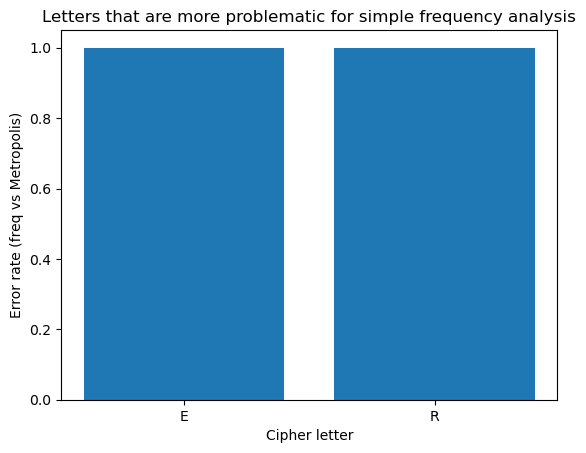

The frequencies in the text are: 

The frequencies in the text are: 

The frequencies in the text are: 

The frequencies in the text are: 

The frequencies in the text are: 


Length vs positional agreement (freq vs Metropolis):
L =  100, agreement = 0.00%
L =  200, agreement = 0.00%
L =  400, agreement = 0.00%
L =  800, agreement = 0.00%
L = 1944, agreement = 0.00%


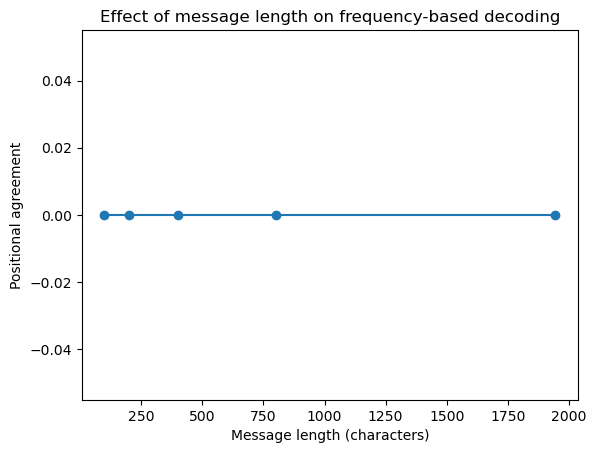

In [63]:
# Extra analysis for Q8 – keep the original Part 8 code as it is, and just run this cell underneath.
# ------------------------
# 1) per-letter behaviour
# ------------------------

# for each cipher letter, see how often freq and Metropolis agree / disagree
def per_letter_stats(ciphertext, decoded_freq, decoded_metro):
    stats = {}
    for c in character_list:
        stats[c] = {
            "count": 0,
            "same": 0,
            "diff": 0
        }

    n = min(len(ciphertext), len(decoded_freq), len(decoded_metro))
    for i in range(n):
        c = ciphertext[i]
        f = decoded_freq[i]
        m = decoded_metro[i]
        stats[c]["count"] += 1
        if f == m:
            stats[c]["same"] += 1
        else:
            stats[c]["diff"] += 1

    for c in character_list:
        cnt = stats[c]["count"]
        if cnt > 0:
            stats[c]["error_rate"] = stats[c]["diff"] / cnt
        else:
            stats[c]["error_rate"] = None
    return stats


letter_stats = per_letter_stats(ciphertext, decoded_freq, decoded_metro)

letters = []
error_rates = []
counts = []

for c in character_list:
    if letter_stats[c]["count"] > 0 and letter_stats[c]["error_rate"] is not None:
        letters.append(c)
        error_rates.append(letter_stats[c]["error_rate"])
        counts.append(letter_stats[c]["count"])

print("Per-letter error rates (simple frequency vs Metropolis):")
for c, er, cnt in zip(letters, error_rates, counts):
    print(f"{c}: error_rate = {er:.2f}, count = {cnt}")

# bar chart: which letters are more problematic?
plt.figure()
plt.bar(range(len(letters)), error_rates)
plt.xticks(range(len(letters)), letters)
plt.xlabel("Cipher letter")
plt.ylabel("Error rate (freq vs Metropolis)")
plt.title("Letters that are more problematic for simple frequency analysis")
plt.show()


# ----------------------------------------
# 2) Dependence on message length (prefixes)
# ----------------------------------------

lengths = [100, 200, 400, 800, len(ciphertext)]
lengths = [L for L in lengths if L <= len(ciphertext)]

length_results = []

for L in lengths:
    ct_sub = ciphertext[:L]

    # Simple frequency-based decode on the shorter message
    english_freqs_sub = get_frequency(moby_new)
    freq_map_sub = get_letter_map_from_frequency(ct_sub, english_freqs_sub, verbose=False)
    dec_freq_sub = decode(ct_sub, freq_map_sub)

    # Metropolis/bigram decode on the shorter message
    bigram_stats_sub = all_bigram_freqs(moby_new, character_list)
    dec_metro_sub = metropolis(ct_sub, character_list, 20000, 1.0, bigram_stats_sub, verbose=False)
    agree_sub = positional_overlap(dec_freq_sub, dec_metro_sub)
    length_results.append((L, agree_sub))

print("\nLength vs positional agreement (freq vs Metropolis):")
for L, a in length_results:
    print(f"L = {L:4d}, agreement = {a*100:.2f}%")

plt.figure()
plt.plot([x[0] for x in length_results],
         [x[1] for x in length_results],
         marker="o")
plt.xlabel("Message length (characters)")
plt.ylabel("Positional agreement")
plt.title("Effect of message length on frequency-based decoding")
plt.show()

One can also consider the probability that the decoded results are correct for each of the deciphering methods


Letter probability vs success probability for the simple method:
E: P(c) ~ 0.001,  P(correct|c) ~ 0.000
R: P(c) ~ 0.001,  P(correct|c) ~ 0.000


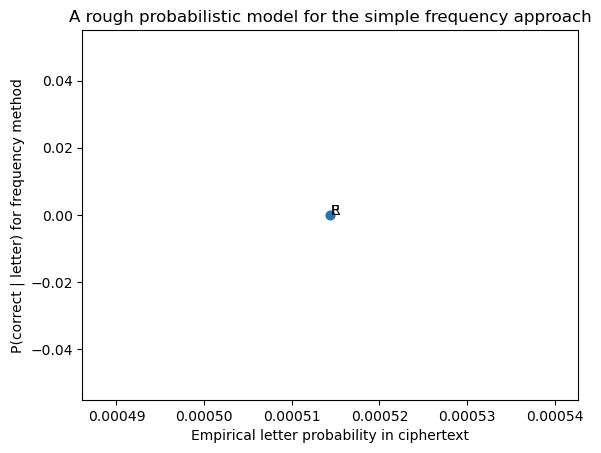

In [64]:
# ----------------------------------------
# 3) A rough probabilistic picture
#    P(correct | letter) vs P(letter)
# ----------------------------------------

total_len = len(ciphertext)

letter_probs = []
success_probs = []
used_letters = []

for c in character_list:
    cnt = letter_stats.get(c, {}).get("count", 0)
    er = letter_stats.get(c, {}).get("error_rate", None)
    if cnt > 0 and er is not None:
        p_c = cnt / total_len                 # Empirical P(c)
        p_success = 1.0 - er                  # Empirical P(correct | c)
        used_letters.append(c)
        letter_probs.append(p_c)
        success_probs.append(p_success)

print("\nLetter probability vs success probability for the simple method:")
for c, p_c, p_s in zip(used_letters, letter_probs, success_probs):
    print(f"{c}: P(c) ~ {p_c:.3f},  P(correct|c) ~ {p_s:.3f}")

plt.figure()
plt.scatter(letter_probs, success_probs)
for c, x, y in zip(used_letters, letter_probs, success_probs):
    plt.text(x, y, c)

plt.xlabel("Empirical letter probability in ciphertext")
plt.ylabel("P(correct | letter) for frequency method")
plt.title("A rough probabilistic model for the simple frequency approach")
plt.show()


We can also inspect what difference swapping any two characters, such as "A" and "B" has on the Score statistic.

In [65]:
# Testing cell
s1 = score(ciphertext, all_bigram_freqs_dicts)
s2 = score(swap_of_char(ciphertext, "A", "B"), all_bigram_freqs_dicts)
print(s1, s2)

-10928.39504376942 -11319.893038950917


<a id="section4.3"></a>
### <u>Section4.3
#### Using Graphical Representation

Looking back at the Metropolis Algorithm, and analysing its progress over time, there are many different quantities that factor into its effectiveness. In this section, we will look at extracting these quantities from the Metropolis function and analysing them using graphical representation.

For example: by inputting different values for the temperature T into this function, we can plot multiple lines on a single graph. If we show this on a graph of number of steps N against values of the score function $S(m)$, this allows for an easy comparison of how the algorithm's success is impacted by certain quantities.
 
After exploring several of these quantities, we will analyse the outputs and compare our individual conclusions for any similarities in behaviour.

**Here are the three quantities we are extracting from the Metropolis Algorithm:**
* The Score Function $S(m)$,
* The Temperature Parameter $T$,
* The Iteration Count $N$,

#### <u>General Score Analysis

We will call the Metropolis function and then plot the data as follows:

In [67]:
# Collecting the Score Function data needed for the graphs:
# For fairness, we will use the same coded message for majority of these graphs, then we will generalise from our results
our_message = get_coded_message(2)
final_text, score_history = metropolis(our_message, character_list, 20000, 1, all_bigram_freqs_dicts, verbose = False)

x_values = list(range(len(score_history)))
#y_values = ? #

# Size of the figure
plt.figure(figsize =  (10, 6))

# Plot the graph
plt.plot(x_values, y_values, label = "Score Function $S(m)$")

# Label the axes
plt.xlabel("N")
plt.ylabel("$S(m)$")

# Show our completed figure
plt.title("Analysis of the Score Function (with T = 1)")
plt.legend()
plt.show()

NameError: name 'y_values' is not defined

<Figure size 1000x600 with 0 Axes>

At first glance, we can instantly conclude that the greater the number of steps ($N$) our function iterates through, the inevitably better our decoded message is, where 'better' means achieving almost correct English (closer than before the function was called). In this particular case, we can see from the graph that our function has reached stable state within our set parameter $T$ (which is currently set at $T=1$) after the inexact value $N=3750$. It is after this point (where the graph plateaus) the algorithm has the best approximation to our original message - or possibly the fully decoded message.

Generally, we will continue to see this relationship with $N$ throughout this section. As well as this, the graphs we draw will have almost the same shape. 

This means that each will start at the point $(min${$S(m)$}$, N=0)$, and end at $(max${$S(m)$}$, N=2000)$. We will keep $N$ constant throughout this section since the only effect this quantity has on our graph is where it stops. Because of this conclusion, when the Metropolis Algorithm uses this coded message in particular the number of steps used could be shortened to around $N=3700$ to reduce unnecessary memory usage and time per cycle.

#### <u>What effect does Simulated Annealing have on the algorithm?

Simulated Annealing is (10) the process of finding the optimal solution when there are many solutions for the same problem. It involves incrementally reducing the randomness in the problem solving process in order to eventually come to, for the whole space, the most optimal solution.

In [ ]:
# NOW WE CREATE 3 DIFFERENT COMPARISON GRAPHS:

# SIMULATED ANNEALING: True
final_text, sa_true_score_history = metropolis(our_message, character_list, 20000, 1, all_bigram_freqs_dicts, verbose = False, simulated_annealing = True)
# SIMULATED ANNEALING: False
final_text, sa_false_score_history = metropolis(our_message, character_list, 20000, 1, all_bigram_freqs_dicts, verbose = False, simulated_annealing = False)

# Size of the figure
plt.figure(figsize = (10, 6))

# Plot the graph
plt.plot(x_values, sa_true_score_history, label = "Score Function $S(m)$ when Simulated Annealing is True")
plt.plot(x_values, sa_false_score_history, label = "Score Function $S(m)$ when Simulated Annealing is False")

# Label the axes
plt.xlabel("N")
plt.ylabel("$S(m)$")

# Show title and legend
plt.title("Analysis of the Score Function with and without Simulated Annealing")
plt.legend()
plt.show()

Moving onto our first comparative graph where we are trialing the difference between the use of Simulated Annealing (S.A) and the lack of it. Overall it seems the use of S.A only affects the rate of convergence of our algorithm. This can be said because the blue line (where S.A=True) reaches its maximum score value before the orange line, yet neither situation yields a better overall result. This is because, around $N=3750$, both lines maintain the same score value. Meaning that because the same text is used in both scenarios, both instances decode the message with 'equal sounding' English- although this won't necessarily mean the final message will be the same for both iterations. Morever, the orange function takes longer to get to it's version of a final decryption, so using S.A would allow the computer to finish running the algorithm a lot faster.
 
Another important feature on this graph is when the two lines overlap. It is at these points that the quality of the decryption is mathematically identical for both functions.

Therefore, from this behaviour analysis, we can conclude that the use of Simulated Annealing is a more advised approach to the Metropolis Algorithm.

#### <u>What effect does Temperature have on the algorithm?

The temperature $T$ is a parameter in our Metropolis funcion, thus we can investigate how our results depend upon $T$.

In [ ]:
# TEMPERATURE:
# T = 10:
final_text, T10_score_history = metropolis(our_message, character_list, 20000, 10, all_bigram_freqs_dicts, verbose = False)
# T = 0.1:
final_text, T01_score_history = metropolis(our_message, character_list, 20000, 0.1, all_bigram_freqs_dicts, verbose = False)
# T = 0.00005:
final_text, Tsmall_score_history = metropolis(our_message, character_list, 20000, 0.00005, all_bigram_freqs_dicts, verbose = False)


# Size of the figure
plt.figure(figsize = (10, 6))

# Plot the graph
plt.plot(x_values, T10_score_history, label = "Score Function $S(m)$ when T = 10")
plt.plot(x_values, T01_score_history, label = "Score Function $S(m)$ when T = 0.1")
plt.plot(x_values, Tsmall_score_history, label = "Score Function $S(m)$ when T = 0.00005")

# Label the axes
plt.xlabel("N")
plt.ylabel("$S(m)$")

# Show title and legend
plt.title("Analysis of the Score Function (with varying T values)")
plt.legend()
plt.show()

When $T = 10$: The fluctuations with this line, that continue with every iteration $N$, shows that the algorithm is more willing to accept a 'worse' decryption than a better one. This function never settles (never plateaus) for a solution of the decoded message and will most likely continue to fluctuate around the optimal solution with no sign of settling no matter the size of $N$. From this we can say that if a $T$ value is too high, we lose a lot of precision with the algorithm.

When $T = 0.1$: We can see that this function does not produce the most optimal solution available. This is because the Score value which is settled upon is approximately $S(m)=-2200$, whereas our best solution has a maximum score value of $S(m)=-1750$.

When $T = 0.00005$: The general shape of this line is strikingly similar to $T = 0.1$, even plateauing at similar (if not the same) number of iterations (roughly $N=2750$). However the main difference is the maximum Score value reached. This implies that the smallest value of $T$ obtains the best decoded message out of the other two functions. Since within the algorithm, the smaller the value of $T$, the less likely the algorithm is to choose a 'worse' decryption of the given coded message. Thus it only chooses better solutions, or none at all. Meaning it is possible to get stuck before we have reached the best solution available to us.

From this particular analysis, we can conclude that the smaller the chosen value of $T$, the better the yield for the algorithm.

#### <u>How does the length of our given messages impact the outcome of the algorithm?

Length of our coded messages was one of the main factors that made certain deciphering methods less effective. Thus we should explore how the Metropolis Algorithm performs when dealing with different length of coded messages.

In [ ]:
# Create a figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Since the Metropolis Algorithm is randon, we must choose two specific messages in order to fairly analyse our results
long_message = get_coded_message(2)
short_message = get_coded_message(6)



# --- LEFT GRAPH: RAW SCORES  ---
# LENGTH (Setting the Temperature back to T = 1):
# Long text:
final_text, long_score_history = metropolis(long_message, character_list, 20000, 1, all_bigram_freqs_dicts, verbose = False)
long_text_length = len(long_message)

# Short text:
# Reassigning our 7th coded message:
final_text, short_score_history = metropolis(short_message, character_list, 20000, 1,  all_bigram_freqs_dicts, verbose = False)
short_text_length = len(short_message)


# Plot both functions on the correct graph
ax1.plot(x_values, long_score_history, label = f"Score Function $S(m)$ with a longer text of length {long_text_length}", color = 'tab:blue')
ax1.plot(x_values, short_score_history, label = f"Score Function $S(m)$ with a shorter text of length {short_text_length}", color = 'tab:orange')

ax1.set_title("Raw Text Lengths")
ax1.set_xlabel("N Iterations")
ax1.set_ylabel("Score Function Values S(m)")
ax1.legend()



# --- RIGHT GRAPH: SCALED SCORES  ---
# We divide by the length of the specific text used to generate their normalised score values
scaled_long = [s / len(long_message) for s in long_score_history]
scaled_short = [s / len(short_message) for s in short_score_history]

# Plot the graph
ax2.plot(x_values, scaled_long, label = '$S(m)$ with scaled longer Text', color = 'tab:blue')
ax2.plot(x_values, scaled_short, label = '$S(m)$ with scaled shorter Text', color = 'tab:orange')

ax2.set_title("Normalised Scores (Score / Length)")
ax2.set_xlabel("N")
ax2.set_ylabel("Score Function Values S(m)")
ax2.legend()

# Show the whole figure
plt.suptitle("Analysis of the Score Function (with varying text lengths)", fontsize = 16)
plt.tight_layout() # Adjusts spacing so titles don't overlap
plt.show()

Looking at our raw text functions first, it appears that the shorter message decodes a better result than the longer text, which is shown by the vast difference in maximum Score values. However we know this is misleading because the Score function is a summation, so a shorter message has fewer terms to add up, resulting in a Score value which is closer to zero. This is shown by the orange line having next to no variations in its Score values (remaining bounded between $(-50, -350)$), then plateauing almost instantly. On the other hand, a longer text will have a much larger total Score purely because it has more characters. We can clearly see (between 0 and 2500) that the algorithm is attempting to decode the message, and eventually decodes the message to a suitable degree, as shown by the delayed plateau in the graph, which remains bounded between $(-1800, -2000)$.

The reason why the two functions aren't starting at the same point is because the starting text is different. To the algorithm, one message may look more like English than the other, consequently making one function start at a higher score (lower magnitude) than the other.

It is impossible for these two lines to meet since the Score function is based on how many characters are in the text. Hence the longer text has a massively lower Score (larger magnitude). They also cannot end on the same Score value because no matter how similar the two coded messages are, unless they are the exact same, the final decryption cannot share a Score value.

Since these two lines are so vastly different, it is unfair to analyse them like this, so we must normalise our Score values by dividing them by their respective lengths to obtain the average Score per character. This allows us to compare the differences between these lines with more confidence.

Now having scaled our Score values, we can see even more clearly just how much this algorithm is dependent on the message length. With a longer message the graph is varying in Score between $N = 0$ and $N = 2500$, just like before. However, with a shorter message, we can see clearly now that the graph never plateaus, the variations continue to occur with every step, showing that the algorithm doesn't have enough data within the message to make a satisfactory decryption. Thus, longer messages are easier to decode with the Metropolis algorithm because the bigrams are more likely to occur. Whereas with the shorter messages, the probability of finding a specific bigram is even lower, hence why the algorithm continues to struggle no matter how great the value of $N$.

By normalising our values, we have allowed the lines to overlap, allowing for a fair comparison of convergence.

#### <u>Final Conclusion

Overall, these five different simulations show us that for the Metropolis Algorithm to be successful, the inputs must be optimised first. The general Score graph showed us the the decryption improves quickly in the beginning iterations then plateaus for the rest of the $N$ steps taken. When testing Temperature, we saw that choosing the perfect $T$ value is not simple. Too high and the graph becomes chaotic and unending. but too small and we risk choosing the wrong decryption and losing out on the optimal solution. Simulated Annealing may solve this by finding the solution much faster, therefore allowing some lenience if the wrong $T$ is chosen for the algorithm.

Finally, when comparing two texts of different length, we saw the raw score made the short message seem better, whereas scaling the values proved the exact opposite of this. Therefore, we can confidently conclude that including the use of Simulated Annealing in the Metropolis algorithm on a long coded message provides optimised results.

<a id="Results"></a>
## <u>Results

* Final decoded messages with correct punctuation (and comparison to original message)
* Which method(s) did you use (from questions 2-6)? And why?
* How were these method(s) improved?

<a id="Conclusion"></a>
## <u>Conclusion

During this project we worked to decrypt several coded messages in order to explore Cryptography. We saw that certain properties of the messages meant there were more appropriate methods for each. Interestingly we found we could apply our deciphering methods to non-English messages by slightly adapting the method to consider an array of large foreign texts rather than just Moby-Dick. This project allowed us to analyse the nature of certain deciphering methods, such as the Metropolis Algorithm and then test potential avenues of improvements. 

To improve further, we could have created our own encrypted messages and then used our findings throughout the project to solve them. Importantly the techniques investigated in this project can be applied to secure codes/messages with a range of languages, lengths and encryptions.

<a id="Bibliography"></a> 
## <u>Bibliography

* (1) Uses of Cryptography: https://medium.com/@prashanthreddyt1234/real-life-applications-of-cryptography-162ddf2e917d
* (2) Large sample english text: http://www.gutenberg.org/files/2701/2701-0.txt
* (3) The Adventure of the Dancing Men: https://sherlock-holm.es/stories/html/danc.html
* (4) Definition of Statistical Physics:  https://www.nature.com/research-intelligence/nri-topic-summaries/statistical-physics-and-message-passing-inference-micro-4406
* (5) The Metropolis Algorithm: https://www.sciencedirect.com/topics/computer-science/metropolis-algorithm
* (6) Suez Canal Guardian article: https://www.theguardian.com/world/2021/mar/30/powerful-tugs-and-an-ebbing-tide-how-the-ever-given-was-freed#:~:text=%E2%80%9CBoskalis's%20role%20was%20basically%20to,down%20and%20lift%20the%20bow.
* (7) The Fairy Feller’s Master-Stroke by Queen: https://genius.com/Queen-the-fairy-fellers-master-stroke-lyrics
* (8) A Fiddler In the North https://www.bbc.co.uk/arts/robertburns/works/a_fiddler_in_the_north/
* (9) Words in the English Language: https://wordcounter.io/blog/how-many-words-are-in-the-english-language
* (10) Definition of Simulated Annealing: https://www.geeksforgeeks.org/artificial-intelligence/what-is-simulated-annealing/
 
  Our foreign language texts:
    * French: "https://www.gutenberg.org/cache/epub/2650/pg2650.txt",
    * Spanish: "https://www.gutenberg.org/cache/epub/2000/pg2000.txt",
    * German:  "https://www.gutenberg.org/cache/epub/22367/pg22367.txt",
    * Dutch: "https://www.gutenberg.org/cache/epub/22722/pg22722.txt",
    * Portuguese: "https://www.gutenberg.org/cache/epub/3333/pg3333.txt"